# Data Analyst Professional Practical Exam Submission



# Data validation
The dataset contains 400 rows and 3 columns before cleaning. I have validated every column against the dataset description:

* **guest_id**: There are 400 unique identifiers for the guests. This column is numeric with no missing values, matching the description.

* **loyalty_tier**: This categorical column contains the loyalty level of each guest. There are 400 non-null values, so no data is missing. The categories are consistent with the expected labels.

* **marketing_consen**t: This is a boolean column indicating marketing preference. All 400 rows are populated with no missing values.

## Cleaning Steps:
Because the dataset was already clean and matched the required data types and descriptions perfectly, no rows were dropped and no values needed to be replaced. The data is ready for exploratory analysis.


In [18]:
import pandas as pd
df = pd.read_csv('da_sample_guest_profiles.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   guest_id           400 non-null    int64 
 1   loyalty_tier       400 non-null    object
 2   marketing_consent  400 non-null    bool  
dtypes: bool(1), int64(1), object(1)
memory usage: 6.8+ KB


,guest_id,loyalty_tier,marketing_consent
0,1,None,True
1,2,Platinum,False
2,3,Silver,True
3,4,Silver,False
4,5,None,True


# Exploratory Analysis

In this section, I explore the guest profiles to understand the distribution of loyalty tiers and marketing preferences.

* **Loyalty Tier Distribution**: The data shows that the largest group of guests currently has no loyalty tier assigned. Among those enrolled, "Silver" is the most common tier, followed by "Gold" and "Platinum." This indicates a significant opportunity to convert "None" guests into the loyalty program.

* **Marketing Consent**: The majority of guests in this sample have provided marketing consent. This is a positive sign for the business, as it means there is a direct channel to communicate promotions and loyalty program benefits to the customer base.

## Relationship between Tier and Consent: 
In every category, the number of guests who provided marketing consent significantly outweighs those who did not. Guests already enrolled in a tier show a high propensity for marketing consent, suggesting that engaged members are more open to brand communication.


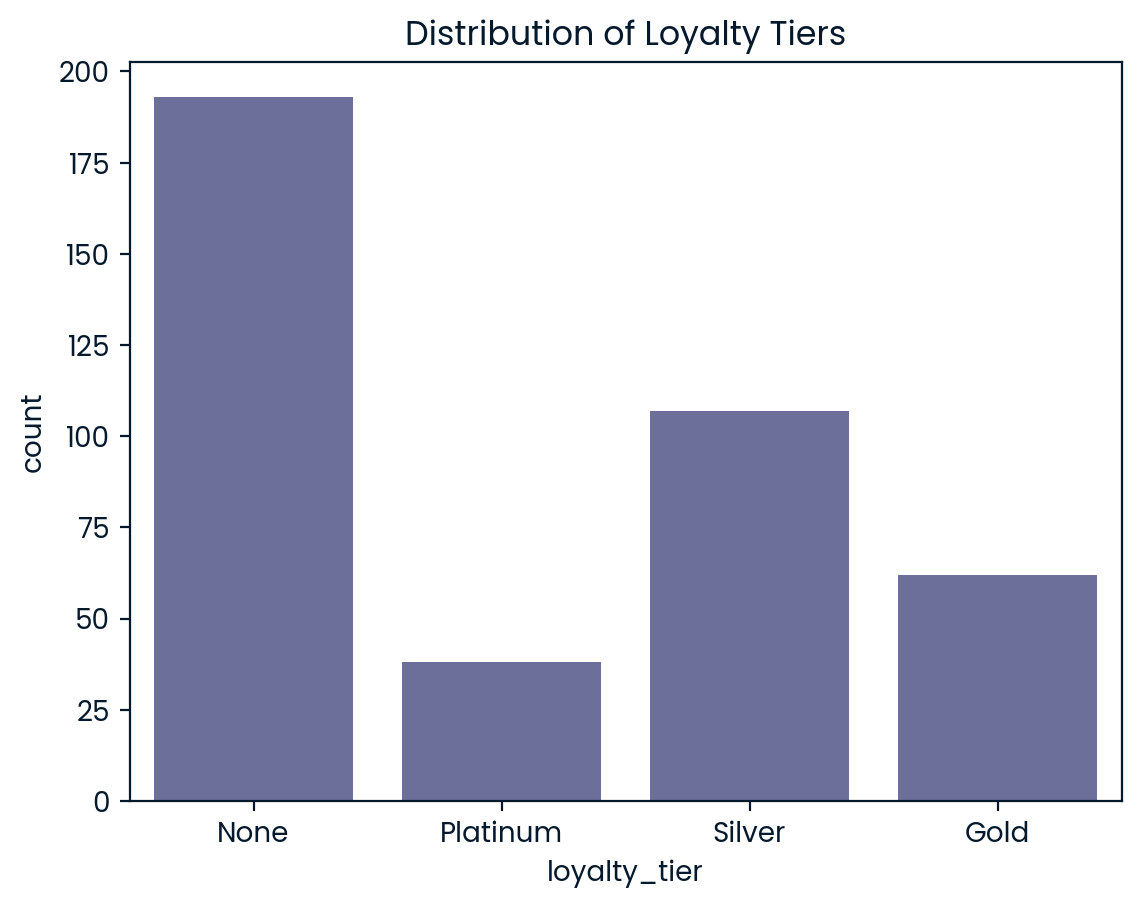

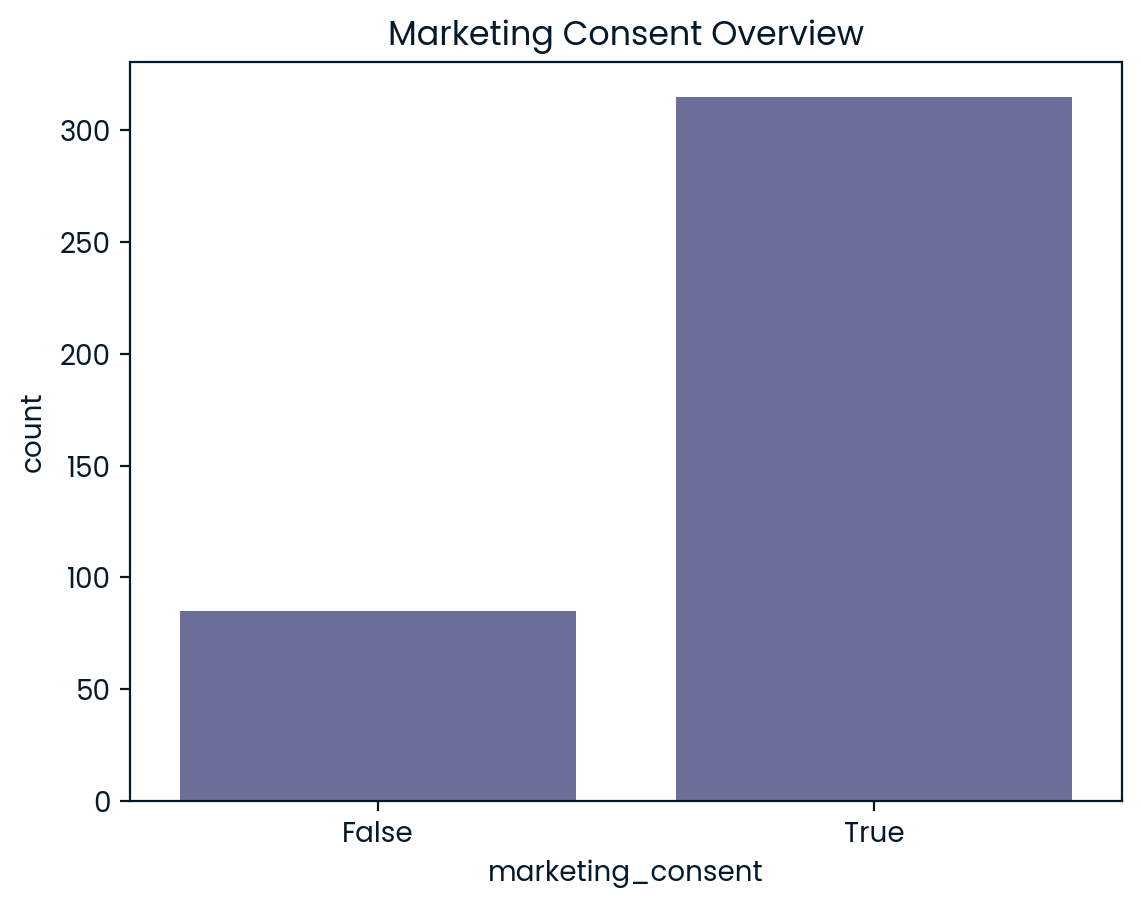

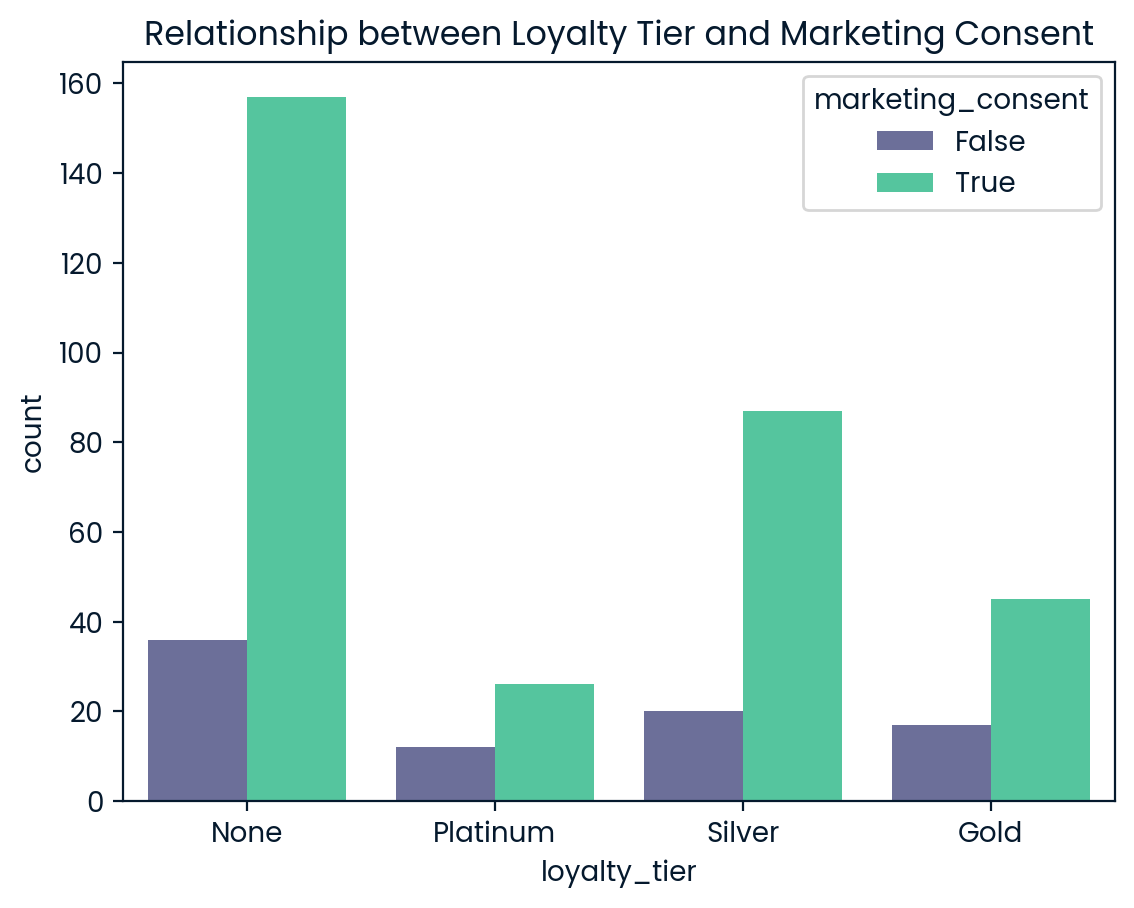

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='loyalty_tier')
plt.title('Distribution of Loyalty Tiers')
plt.show()

sns.countplot(data=df, x='marketing_consent')
plt.title('Marketing Consent Overview')
plt.show()

sns.countplot(data=df, x='loyalty_tier', hue='marketing_consent')
plt.title('Relationship between Loyalty Tier and Marketing Consent')
plt.show()

# Definition of a metric 
To effectively address the business problem of guest engagement, we need a reliable KPI to track progress. I have defined the Loyalty Enrollment Rate as the primary metric for the business to monitor.
Metric Definition
The Loyalty Enrollment Rate is the percentage of total unique guests who have successfully registered for a loyalty tier.

## Strategic Use of the Metric: The business should use this metric to evaluate the success of their customer retention strategies:
- **Monitor Conversion**: It tracks the transition of "None" category guests into active loyalty members.
- **Performance Benchmarking**: It allows management to set quarterly growth targets.
- **Marketing Impact**: By correlating this metric with marketing campaigns, the business can identify which promotions successfully drive program sign-ups.

## Current Baseline Value
Based on the current analysis of 400 unique guests:
- Total Guests: 400
- Active Loyalty Members: 207
- Current Loyalty Enrollment Rate: 51.75%

In [20]:
total_guests = len(df)
none_count = len(df[df['loyalty_tier'] == 'None'])
enrolled_count = total_guests - none_count

enrollment_rate = (enrolled_count / total_guests) * 100

print(f"Total Guests: {total_guests}")
print(f"Enrolled Guests: {enrolled_count}")
print(f"Current Loyalty Enrollment Rate: {enrollment_rate:.2f}%")

Total Guests: 400
Enrolled Guests: 207
Current Loyalty Enrollment Rate: 51.75%


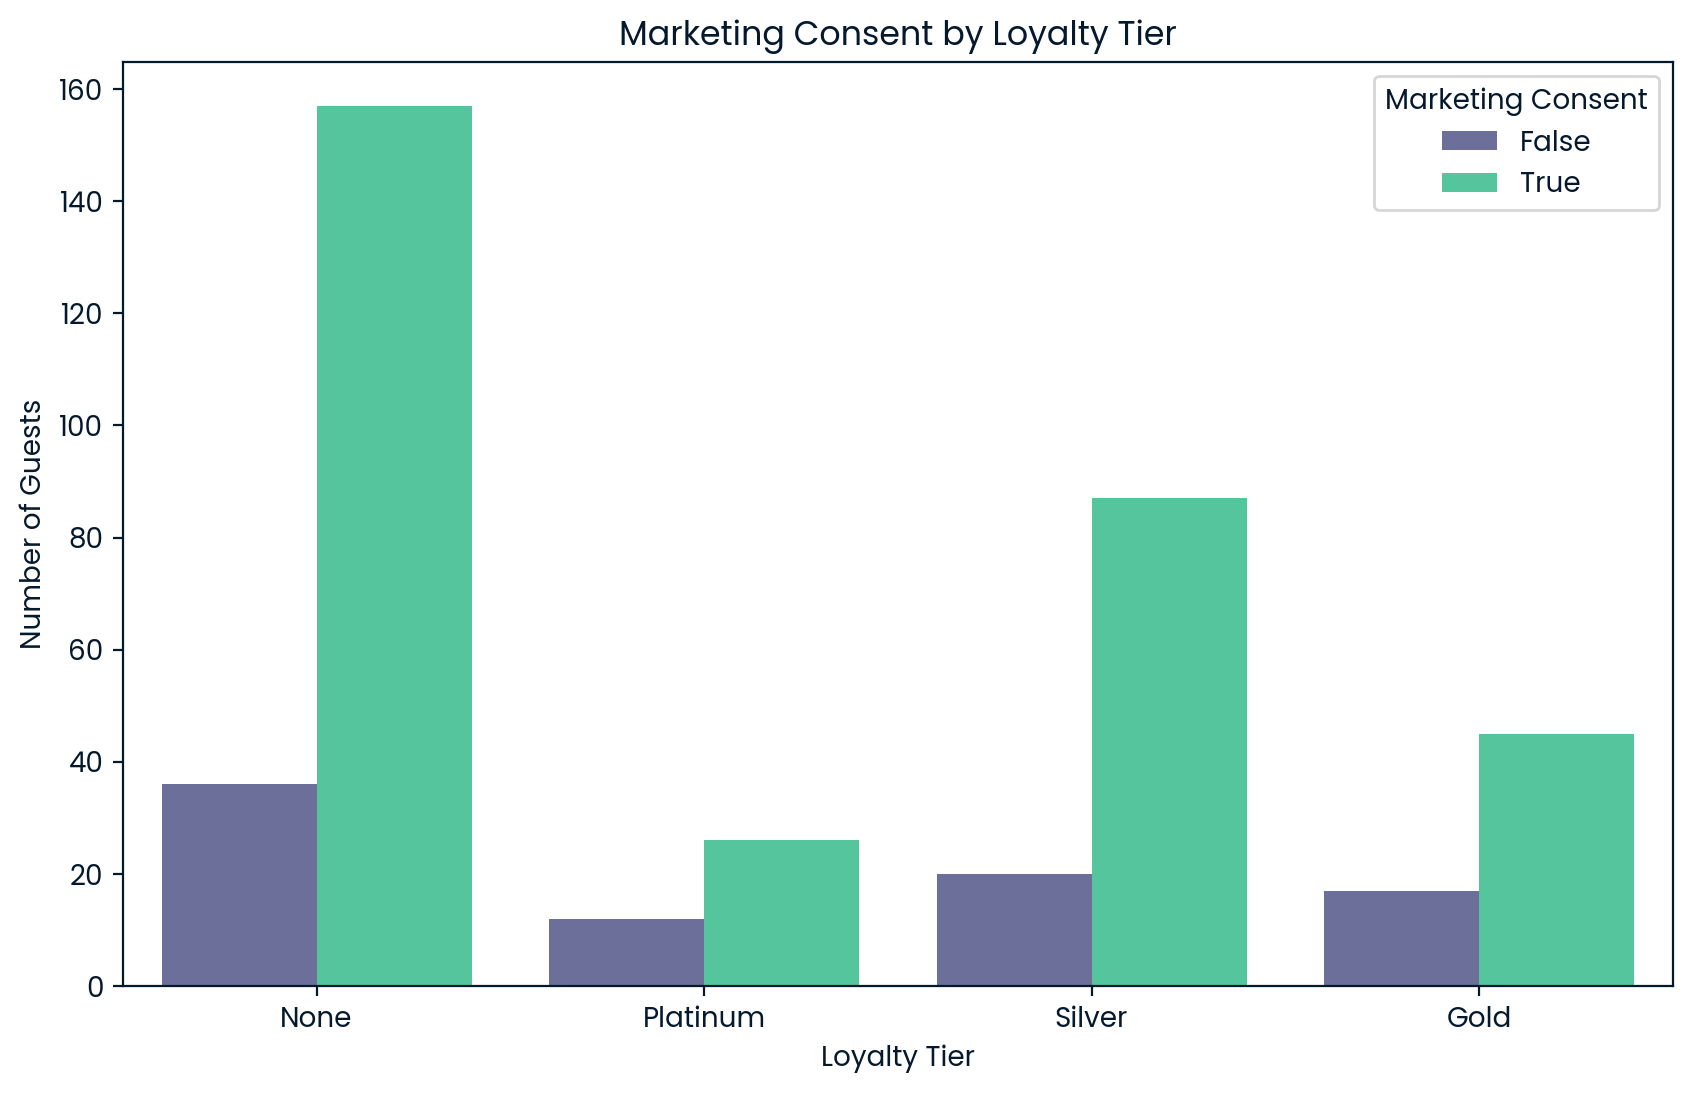

In [21]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='loyalty_tier', hue='marketing_consent')
plt.title('Marketing Consent by Loyalty Tier')
plt.xlabel('Loyalty Tier')
plt.ylabel('Number of Guests')
plt.legend(title='Marketing Consent')
plt.show()

In [22]:
duplicates = df.duplicated(subset=['guest_id']).sum()
print(f"Number of duplicate guest IDs: {duplicates}")

Number of duplicate guest IDs: 0


# Final Summary and Recommendations
Based on the exploratory analysis and the defined metric, I recommend the following actions:

## Key Insights
**Untapped Potential**: Over 48% of the current guest base is not enrolled in a loyalty program.
**High Engagement**: Most guests across all tiers have already opted into marketing communications, providing a clear channel for outreach.

## Recommendations
**Targeted Enrollment Campaign**: Launch a specific email campaign directed at the 157 guests in the "None" category who have already given marketing consent.

**Incentivize Silver Tier**: Since "Silver" is the most common entry tier, offer a one-time "Welcome to Silver" discount to lower the barrier for entry.

**Monthly KPI Review**: Implement a monthly dashboard to track the Loyalty Enrollment Rate to ensure the business stays on track toward its growth goals.

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation